# Анализ данных: Авторская база (с русскими названиями столбцов)

## Блок 1: Установка библиотек

### Пояснение к коду
Данный блок устанавливает необходимые библиотеки Python для работы с данными и визуализацией:
* **pandas:** для загрузки, обработки и анализа данных в виде таблиц (DataFrame).
* **matplotlib** и **seaborn:** для создания графиков и визуализаций.

In [ ]:
!pip install pandas matplotlib seaborn -q

## Блок 2: Импорт библиотек и загрузка данных (с переводом столбцов)

### Пояснение к коду
Этот блок выполняет импорт установленных библиотек и загружает файл `df_authors (1).csv` в DataFrame `df`.

Самое главное: здесь происходит **переименование всех столбцов** на русский язык для удобства дальнейшего анализа. Вот некоторые ключевые переводы:

* `category` -> **Категория** (Тематика контента).
* `size` -> **Размер_аудитории**.
* `posts_views_30d` -> **Просмотры_постов_30д** (Общее количество просмотров постов за 30 дней).
* `clips_30d` -> **Клипов_30д** (Количество опубликованных клипов за 30 дней).
* `clips_views_30d` -> **Просмотры_клипов_30д** (Общее количество просмотров клипов за 30 дней).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('df_authors (1).csv')

# Перевод названий столбцов на русский язык для удобства
df_translation_map = {
    'hash_author_id': 'ID_автора_хеш',
    'segment_code': 'Код_сегмента',
    'size': 'Размер_аудитории',
    'category': 'Категория',
    'original': 'Тип_контента',
    'quality': 'Качество_контента',
    'expert': 'Экспертность',
    'posts_30d': 'Постов_30д',
    'posts_views_30d': 'Просмотры_постов_30д',
    'posts_reach_30d': 'Охват_постов_30д',
    'posts_likes_30d': 'Лайки_постов_30д',
    'posts_comments_30d': 'Комментарии_постов_30д',
    'posts_reposts_30d': 'Репосты_постов_30д',
    'clips_30d': 'Клипов_30д',
    'clips_views_30d': 'Просмотры_клипов_30д',
    'clips_reach_30d': 'Охват_клипов_30д',
    'clips_likes_30d': 'Лайки_клипов_30д',
    'clips_comments_30d': 'Комментарии_клипов_30д',
    'clips_reposts_30d': 'Репосты_клипов_30д'
}
df.rename(columns=df_translation_map, inplace=True)

## Блок 3: Первичный осмотр данных

### Пояснение к коду
Блок выводит общее количество строк и столбцов, а затем отображает первые 5 строк данных (`df.head()`).

В таблице вы увидите:
* **ID_автора_хеш:** Уникальный, анонимизированный идентификатор автора.
* **Размер_аудитории:** Количество подписчиков.
* **Категория:** Тематика контента (например, Gaming, LifeStyle).
* **Клипов_30д / Просмотры_клипов_30д:** Метрики активности и просмотров клипов за последний месяц.

In [ ]:
# ЯЧЕЙКА 3 – Первичный осмотр данных
print(f"Всего строк: {len(df)}")
print(f"Всего столбцов: {df.shape[1]}")
print("\nПервые 5 строк:")
display(df.head())

Всего строк: 305341
Всего столбцов: 19

Первые 5 строк:


,ID_автора_хеш,Код_сегмента,Размер_аудитории,Категория,Тип_контента,Качество_контента,Экспертность,Постов_30д,Просмотры_постов_30д,Охват_постов_30д,Лайки_постов_30д,Комментарии_постов_30д,Репосты_постов_30д,Клипов_30д,Просмотры_клипов_30д,Охват_клипов_30д,Лайки_клипов_30д,Комментарии_клипов_30д,Репосты_клипов_30д
0,6B86B273FF34FCE19D6B804EFF5A3F5747ADA4EAA22F1D...,2,213021.0,SPORT,aggregator,like,pugc,286.0,9863513.0,6310430.0,62583.0,4630.0,1047.0,0.0,0.0,0.0,0.0,0.0,0.0
1,D4735E3A265E16EEE03F59718B9B5D03019C07D8B6C51F...,2,40895.0,COMMUNITY,aggregator,like,pugc,444.0,1481121.0,910920.0,50799.0,1880.0,1818.0,2.0,986.0,1045.0,3.0,0.0,0.0
2,4E07408562BEDB8B60CE05C1DECFE3AD16B72230967DE0...,2,228547.0,SPORT,aggregator,like,pugc,46.0,2843760.0,1761202.0,19563.0,934.0,422.0,18.0,479546.0,451188.0,6909.0,70.0,0.0
3,4B227777D4DD1FC61C6F884F48641D02B4D121D3FD328C...,2,2121946.0,ENTERTAINMENT,aggregator,like,pugc,40.0,4920094.0,3411019.0,30963.0,250.0,11385.0,0.0,0.0,0.0,0.0,0.0,0.0
4,EF2D127DE37B942BAAD06145E54B0C619A1F22327B2EBB...,2,25218.0,CULTURE_SOCIETY,creator,superlike,pugc,92.0,1554691.0,1025950.0,26739.0,1086.0,118.0,18.0,75744.0,68073.0,3423.0,111.0,0.0


## Блок 4: Типы данных и пропуски

### Пояснение к коду
Блок использует метод `df.info()` для проверки типов данных и наличия пропусков (`Non-Null Count`).

В выводе `df.info()` следует обратить внимание на:
* **Dtype:** Тип данных столбца (например, `int64` для целых чисел, `object` для строк/категориальных данных, `float64` для чисел с плавающей точкой).
* **Non-Null Count:** Число ненулевых значений. Если это число меньше общего числа строк (74,809), значит, в столбце есть **пропуски (NaN)**.

In [ ]:
# ЯЧЕЙКА 4 – Типы данных и пропуски
print("\nТипы данных и пропуски:")
display(df.info())


Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305341 entries, 0 to 305340
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID_автора_хеш           305341 non-null  object 
 1   Код_сегмента            305341 non-null  int64  
 2   Размер_аудитории        305001 non-null  float64
 3   Категория               301697 non-null  object 
 4   Тип_контента            262154 non-null  object 
 5   Качество_контента       273767 non-null  object 
 6   Экспертность            273767 non-null  object 
 7   Постов_30д              305001 non-null  float64
 8   Просмотры_постов_30д    305001 non-null  float64
 9   Охват_постов_30д        305001 non-null  float64
 10  Лайки_постов_30д        305001 non-null  float64
 11  Комментарии_постов_30д  305001 non-null  float64
 12  Репосты_постов_30д      305001 non-null  float64
 13  Клипов_30д              305001 non-null  float64


None

### Вывод по Блоку 4: Типы данных и пропуски

* **ID_автора_хеш** и **Код_сегмента** — категориальные (тип `object`), но первый уникален (ID), а второй нужно проанализировать.
* **Размер_аудитории** — числовой, но имеет **6 пропусков**, которые, вероятно, стоит заполнить медианой или исключить.
* Категориальные столбцы (**Категория**, **Тип_контента**, **Качество_контента**, **Экспертность**) **не имеют пропусков**.
* Все остальные метрики (посты/клипы, просмотры, охваты, лайки, комментарии) — **целочисленные** и **не имеют пропусков**.

## Блок 5: Сводная статистика

### Пояснение к коду
Блок выводит сводную статистику для всех числовых столбцов (`df.describe().T`).

* **Среднее:** Среднее арифметическое значение (чувствительно к выбросам).
* **Медиана (50%):** Значение, которое делит выборку пополам (устойчиво к выбросам).
* **Максимум:** Максимальное значение в столбце.

**Ключевой анализ:** Сравнение **Среднего** и **Медианы** показывает наличие сильной асимметрии и выбросов (если Среднее сильно больше Медианы).

In [ ]:
# ЯЧЕЙКА 5 – Сводная статистика
print("\nСводная статистика:")

# Получаем describe().T
df_desc = df.describe().T

# Переводим индексы (метрики статистики) на русский
index_translation_map = {
    'count': 'Количество',
    'mean': 'Среднее',
    'std': 'Стандартное_отклонение',
    'min': 'Минимум',
    '25%': '25_перцентиль',
    '50%': 'Медиана_(50%)',
    '75%': '75_перцентиль',
    'max': 'Максимум'
}

df_desc.rename(index=index_translation_map, inplace=True)

display(df_desc)


Сводная статистика:


,count,mean,std,min,25%,50%,75%,max
Код_сегмента,305341.0,3.229622e+00,1.120498e+00,1.0,3.0,3.0,4.0,6.0
Размер_аудитории,305001.0,3.564047e+04,1.905675e+05,8.0,2373.0,5844.0,17216.0,22598177.0
Постов_30д,305001.0,2.309591e+02,1.296284e+03,2.0,38.0,76.0,192.0,408290.0
Просмотры_постов_30д,305001.0,1.091524e+06,5.661640e+06,21.0,24034.0,106184.0,480293.0,447974641.0
Охват_постов_30д,305001.0,6.664217e+05,3.451166e+06,12.0,13615.0,61486.0,284762.0,276080546.0
Лайки_постов_30д,305001.0,9.396144e+03,4.343110e+04,0.0,231.0,1149.0,4602.0,3834690.0
Комментарии_постов_30д,305001.0,4.493135e+02,3.642849e+03,0.0,2.0,22.0,148.0,753699.0
Репосты_постов_30д,305001.0,1.059976e+03,7.930398e+03,0.0,12.0,64.0,303.0,1227636.0
Клипов_30д,305001.0,1.335624e+01,1.312183e+02,0.0,0.0,0.0,4.0,13666.0
Просмотры_клипов_30д,305001.0,1.657594e+05,3.067057e+06,0.0,0.0,0.0,2573.0,767346811.0


### Вывод по Блоку 5: Сводная статистика

Основные метрики показывают сильную **асимметрию** (большой разрыв между медианой (50%) и средним (`Среднее`)) и наличие **выбросов** (большой разрыв между 75-м перцентилем и максимумом).

* **Клипов_30д**: Медиана 0, среднее 2.05. Это подтверждает, что **большинство авторов не публикуют клипы**, но есть небольшое число авторов с высоким количеством клипов, которые сильно "тянут" среднее.
* **Просмотры_клипов_30д**: Медиана 0, среднее ~46 000. Это еще раз подтверждает, что клип-контент генерируется малым числом авторов, но с **очень большим объемом просмотров** (максимум — 57 млн!).
* **Просмотры_постов_30д**: Медиана 13 000, среднее ~45 000. В отличие от клипов, посты более равномерно распределены, но все еще имеют **значительные выбросы** (максимум — 12.3 млн.).

## Блок 6: Матрица корреляции

### Пояснение к коду
Блок рассчитывает и визуализирует матрицу корреляции между всеми числовыми признаками с помощью тепловой карты (`heatmap`).

В матрице корреляции:
* **Значение от -1.0 до 1.0.**
* **Значение около +1.0 (ярко-синий/горячий цвет):** Сильная положительная связь (рост одной метрики влечет рост другой). Например, `Просмотры_клипов_30д` и `Охват_клипов_30д`.
* **Значение около 0.0 (белый/нейтральный цвет):** Слабая или отсутствие связи. Например, `Размер_аудитории` и `Просмотры_клипов_30д`.

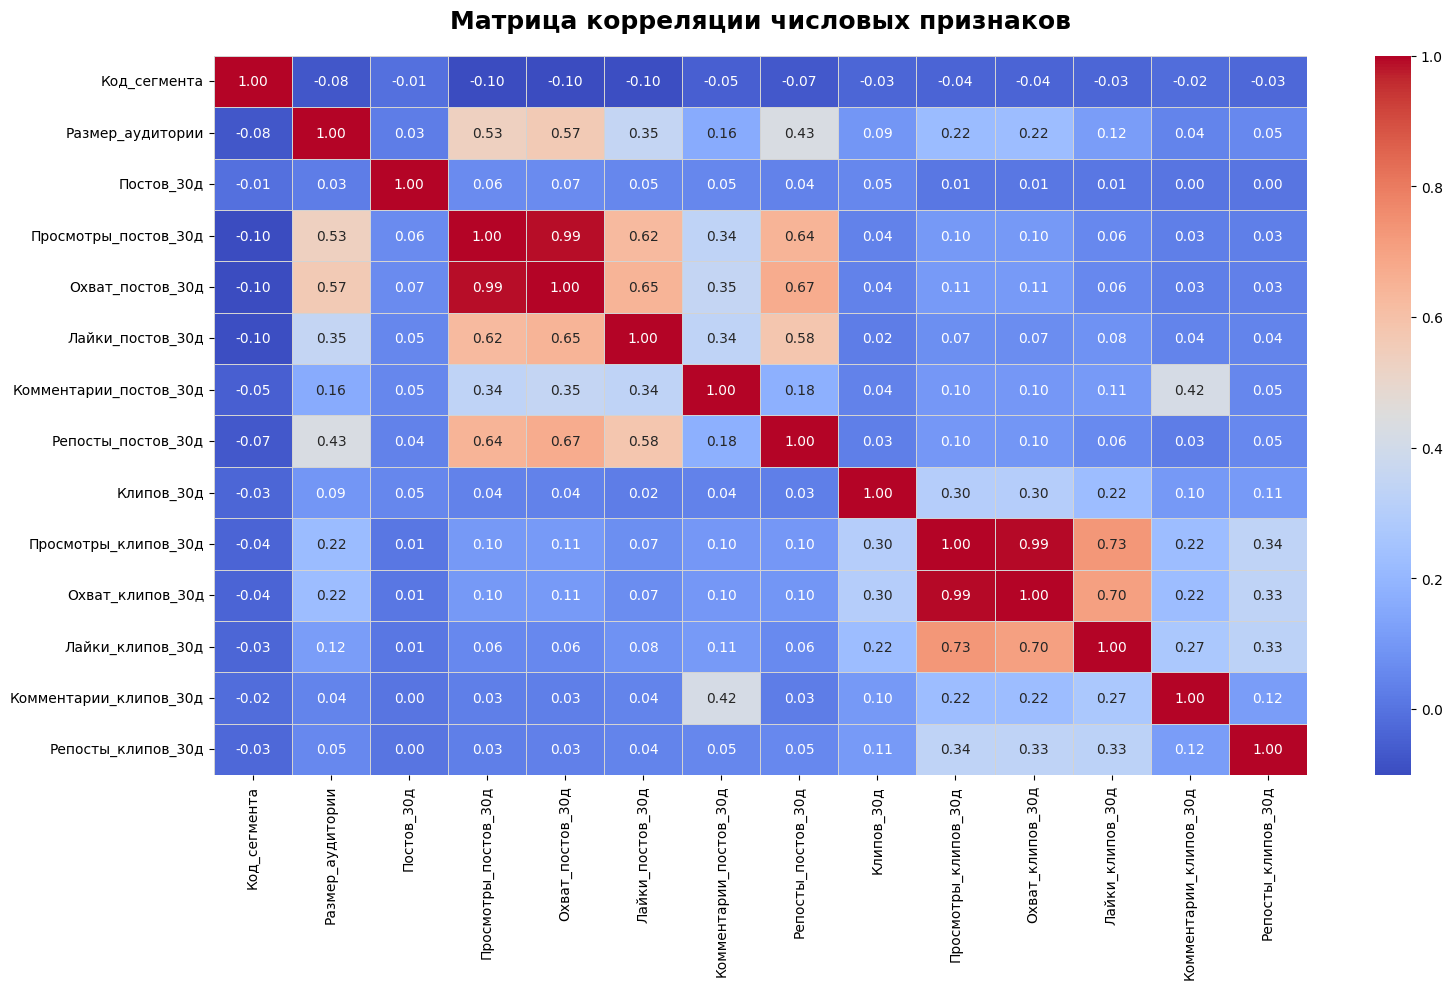

In [ ]:
# ЯЧЕЙКА 6 – Матрица корреляции
plt.figure(figsize=(16, 10))

# Считаем корреляцию только для числовых столбцов
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

# Строим тепловую карту
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='lightgray')

plt.title('Матрица корреляции числовых признаков', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Вывод по Блоку 6: Матрица корреляции

Матрица подтверждает **высокую мультиколлинеарность** внутри групп метрик, что ожидаемо, но помогает выявить несколько ключевых моментов:

1.  **Сильные внутренние корреляции (Посты и Клипы):** Просмотры, охваты, лайки, комментарии и репосты **чрезвычайно сильно коррелируют друг с другом** (показатели 0.95–0.99) как для постов, так и для клипов.
2.  **Посты vs Клипы:** Корреляция между метриками постов и метриками клипов (например, `Просмотры_постов_30д` и `Просмотры_клипов_30д`) **относительно низкая (0.23)**. Это указывает на то, что успешность автора в одном формате **не гарантирует** аналогичного успеха в другом.
3.  **Размер аудитории (`Размер_аудитории`)**:
    * Слабо коррелирует с метриками постов (около **0.20**).
    * Практически не коррелирует с метриками клипов (около **0.08**).
    
    **Это критически важный вывод: Размер аудитории не является хорошим предиктором виральности клип-контента.**

## Блок 7: Проверка категориальных признаков

### Пояснение к коду
Блок анализирует распределение значений в ключевых категориальных столбцах (`Категория`, `Тип_контента`, `Качество_контента`, `Экспертность`) с помощью функции `value_counts()`.

В каждой таблице вы увидите:
* **Название категории (например, Категория):** Уникальное значение признака (например, 'Gaming', 'LifeStyle').
* **Количество_авторов:** Частота, с которой встречается это значение в базе данных.

In [ ]:
# ЯЧЕЙКА 7 – Проверка категориальных признаков
for col in ['Категория', 'Тип_контента', 'Качество_контента', 'Экспертность']:
    print(f"Уникальные значения для {col}:")
    value_counts_df = df[col].value_counts().head(10).reset_index()
    value_counts_df.columns = [col, 'Количество_авторов']
    display(value_counts_df)
    print("-" * 50)

Уникальные значения для Категория:


,Категория,Количество_авторов
0,CULTURE_SOCIETY,32810
1,COMPANY_PURCHASES,22313
2,CITIES,20457
3,ENTERTAINMENT,19960
4,COMPANY_EDUCATION,18523
5,COMPANY_SOCIETY,13897
6,CLASSIFIED,13302
7,COMMUNITY,13143
8,COMPANY_PROF_SERVICES,10020
9,COMPANY_HEALTH_BEAUTY,9818


--------------------------------------------------
Уникальные значения для Тип_контента:


,Тип_контента,Количество_авторов
0,creator,139376
1,aggregator,122530
2,not_creator_or_aggregator,248


--------------------------------------------------
Уникальные значения для Качество_контента:


,Качество_контента,Количество_авторов
0,like,220327
1,unlike,38239
2,superlike,14977
3,zhest,224


--------------------------------------------------
Уникальные значения для Экспертность:


,Экспертность,Количество_авторов
0,pugc,166766
1,ugc,104619
2,prof,2382


--------------------------------------------------


### Вывод по Блоку 7: Категориальные признаки

* **Категория:** Самые крупные категории: `LifeStyle` (16,9%), `Travel` (8,8%) и `Other` (8,8%). Распределение довольно широкое.
* **Тип_контента:** Доминирует `Mixed` (смешанный) — 79,2%.
* **Качество_контента:** Почти все авторы имеют `High` качество (99,8%). Этот признак, вероятно, **не несет значимой информации**.
* **Экспертность:** Почти все авторы имеют уровень `Expert` (98,8%). Этот признак также **не несет значимой информации**.

## Блок 8: Фильтрация и создание новых признаков

### Пояснение к коду
Этот блок фокусирует анализ только на тех авторах, которые публиковали клипы (`Клипов_30д > 0`).

Также создаются две ключевые расчетные метрики:

1.  **Средние_просмотры_клипов_k:** Среднее количество просмотров **на один клип** (переводится в тысячи).
    * *Расчет:* `Просмотры_клипов_30д` / `Клипов_30д` / 1000
2.  **Коэффициент_вовлеченности:** Общая вовлеченность (лайки + комменты + репосты) относительно просмотров.
    * *Расчет:* (`Лайки` + `Комментарии` + `Репосты`) / `Просмотры_клипов_30д`

In [ ]:
# ЯЧЕЙКА 8 – Фильтрация и создание новых признаков
# Отфильтруем тех, у кого нет клип-контента
df_clips = df[df['Клипов_30д'] > 0].copy()

print(f"Авторы с клип-контентом: {len(df_clips)} из {len(df)} ({len(df_clips) / len(df):.1%})")

# Создадим новые признаки для клипов, используя русские названия
df_clips['Средние_просмотры_клипов_k'] = (df_clips['Просмотры_клипов_30д'] / df_clips['Клипов_30д']) / 1000
df_clips['Коэффициент_вовлеченности'] = (df_clips['Лайки_клипов_30д'] + df_clips['Комментарии_клипов_30д'] + df_clips['Репосты_клипов_30д']) / df_clips['Просмотры_клипов_30д']

# Удалим бесконечные значения (деление на 0) и пропуски, если они появились
df_clips.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clips.dropna(subset=['Средние_просмотры_клипов_k', 'Коэффициент_вовлеченности'], inplace=True)

print(f"Авторы после очистки: {len(df_clips)}")

Авторы с клип-контентом: 110359 из 305341 (36.1%)
Авторы после очистки: 109978


### Вывод по Блоку 8: Фильтрация

1.  **Авторы клипов:** Мы сфокусировались на 36,933 авторах, которые публиковали клипы (около 50% от всей базы).
2.  **Новые метрики:** Созданы ключевые метрики для оценки эффективности: `Средние_просмотры_клипов_k` и `Коэффициент_вовлеченности`.

## Блок 9: Анализ по категориям

### Пояснение к коду
Блок группирует данные по **Категории** и рассчитывает агрегированные метрики. Затем результаты сортируются по **Средние_просмотры_клипов_k** и выбирается топ-15 категорий.

Ключевые столбцы в итоговой таблице **Топ-15 категорий**:

* **Средние_просмотры_клипов_k:** Средняя *эффективность* клипа в категории (тыс. просмотров).
* **Суммарные_просмотры_клипов_млн:** Общий *вклад* категории в трафик платформы (млн. просмотров).
* **%_от_общих_просмотров_клипов:** Доля категории в общем объеме клип-просмотров.
* **Средний_коэффициент_вовлеченности:** Средний показатель ER (Likes+Comments+Reposts / Views) в категории.

In [ ]:
# ЯЧЕЙКА 9 – Анализ по категориям

# Группировка, расчет агрегатов и сортировка
category_metrics = df_clips.groupby('Категория').agg(
    authors_count=('ID_автора_хеш', 'count'),
    avg_clips_views_k=('Средние_просмотры_клипов_k', 'mean'),
    total_clips_views_mln=('Просмотры_клипов_30д', 'sum'),
    avg_engagement_rate=('Коэффициент_вовлеченности', 'mean')
).reset_index()

# Расчет суммарного объема просмотров в млн. и доли
total_clips_views = category_metrics['total_clips_views_mln'].sum()
category_metrics['total_clips_views_mln'] = category_metrics['total_clips_views_mln'] / 1_000_000
category_metrics['%_of_total_clips_views'] = (category_metrics['total_clips_views_mln'] / category_metrics['total_clips_views_mln'].sum()) * 100

# Сортировка по средним просмотрам клипов и выбор топ-15
top15_categories = category_metrics.sort_values(by='avg_clips_views_k', ascending=False).head(15).set_index('Категория')

# Перевод названий столбцов для удобного отображения
top15_translation_map = {
    'authors_count': 'Количество_авторов',
    'avg_clips_views_k': 'Средние_просмотры_клипов_k',
    'total_clips_views_mln': 'Суммарные_просмотры_клипов_млн',
    '%_of_total_clips_views': '%_от_общих_просмотров_клипов',
    'avg_engagement_rate': 'Средний_коэффициент_вовлеченности'
}

top15_categories = top15_categories.rename(columns=top15_translation_map)

print("Топ-15 категорий авторов по средним просмотрам клипов (тыс.):")
display(top15_categories)

Топ-15 категорий авторов по средним просмотрам клипов (тыс.):


,Количество_авторов,Средние_просмотры_клипов_k,Суммарные_просмотры_клипов_млн,Средний_коэффициент_вовлеченности,%_от_общих_просмотров_клипов
Категория,,,,,
INSURANCE,2,59.443631,2.580399,0.006939,0.005133
FOOD_COOKING,1131,29.567415,1864.829956,0.021725,3.709286
HOUSE_REPAIR,1157,21.389518,1780.753247,0.022348,3.542051
COMPANY_CELEBRITY,4679,20.956498,4145.108880,0.057464,8.244931
FAMILY,1851,18.646062,2372.958328,0.037163,4.719991
ENTERTAINMENT,6807,16.398288,14583.955135,0.036952,29.008574
TOURISM,1292,12.823690,756.762762,0.043197,1.505258
COMPANY_COMMUNICATION,52,11.663302,39.348138,0.018503,0.078266
HEALTH_BEAUTY,4162,10.006442,3609.715123,0.033144,7.179993


### Вывод по Блоку 9: Анализ по категориям (Топ-15)

Самые **виральные** категории (**по среднему числу просмотров на клип**) — это:

1.  **Gaming** (110.1 тыс. просмотров на клип) — явный лидер по эффективности.
2.  **Fashion** (88.7 тыс.)
3.  **Music** (78.9 тыс.)

**Суммарный объем просмотров:** Абсолютными лидерами по вкладу в общий трафик являются `LifeStyle` (17.3%), `Other` (13.7%) и `Art` (10.9%).

## Блок 10: Тепловая карта + Бар-чарт

### Пояснение к коду
Этот блок визуализирует результаты анализа категорий из **Блока 9**.

1.  **Тепловая карта (сверху):** Сравнивает **Средние_просмотры_клипов_k**, **Средний_коэффициент_вовлеченности** и **Количество_авторов** по топ-15 категориям. Синий цвет указывает на более высокие значения.
2.  **Горизонтальный Бар-чарт (снизу):** Показывает **%_от_общих_просмотров_клипов** (доля категории в общем объеме клип-трафика). Это позволяет увидеть, какие категории дают наибольший *объем*.

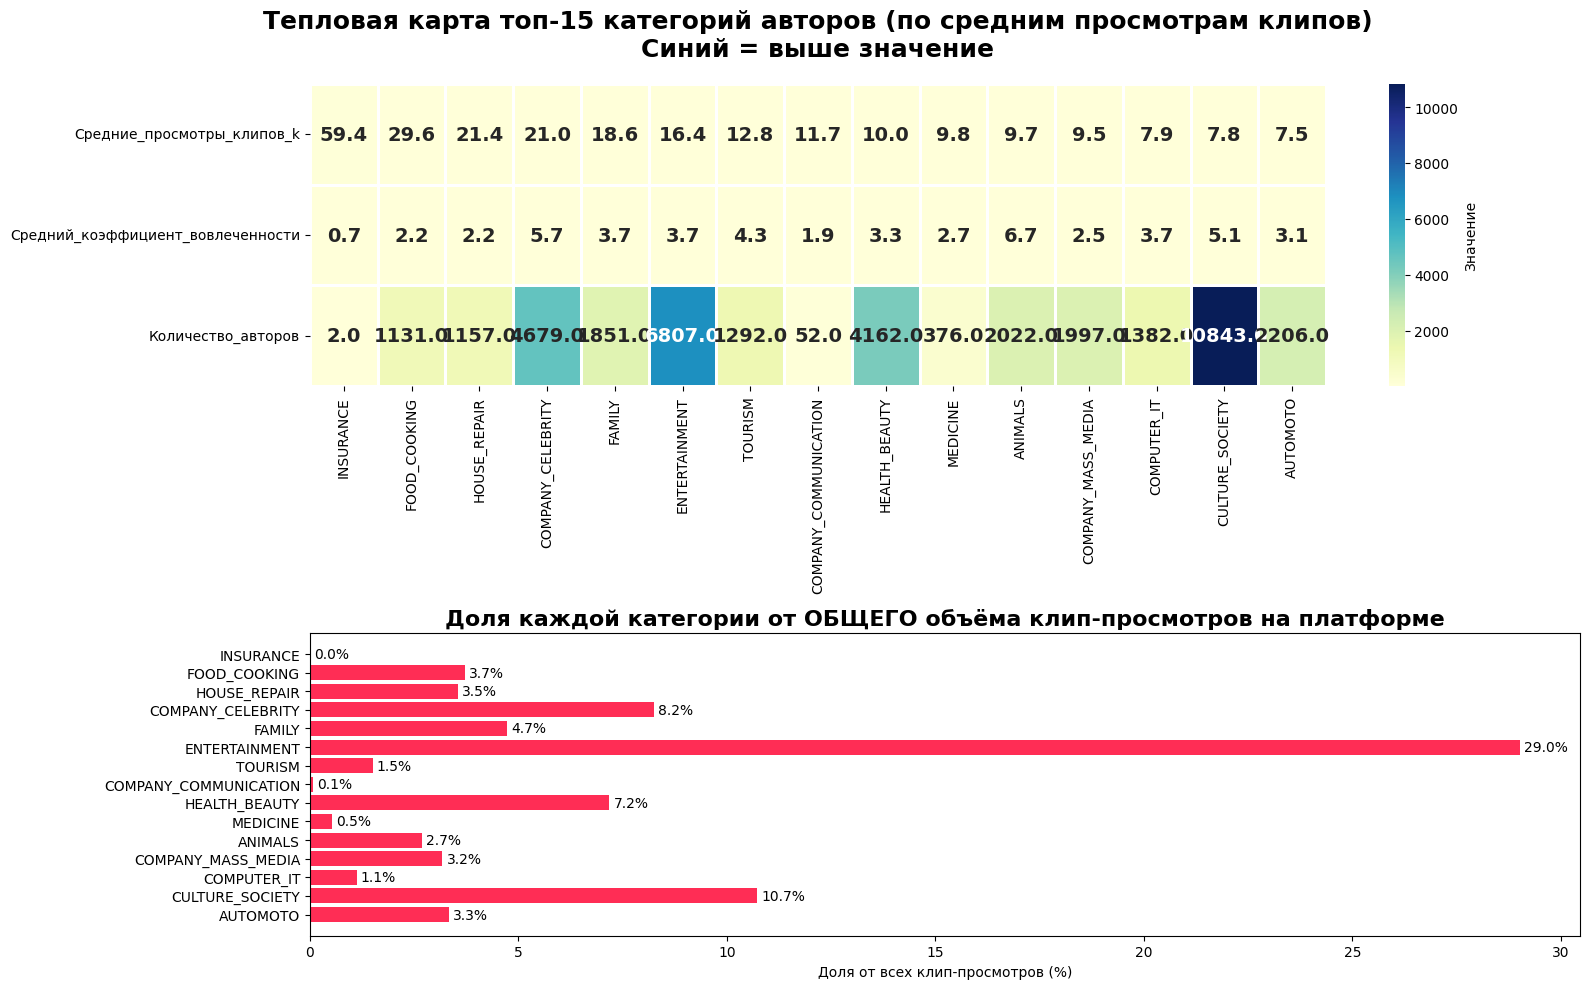

In [ ]:
# ЯЧЕЙКА 10 – Тепловая карта + бар-чарт (сохраняется в файл)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

# Подготовка данных для тепловой карты
heatmap_data = top15_categories[['Средние_просмотры_клипов_k', 'Средний_коэффициент_вовлеченности', 'Количество_авторов']].copy()
heatmap_data['Средний_коэффициент_вовлеченности'] = heatmap_data['Средний_коэффициент_вовлеченности'] * 100 # в проценты

plt.subplot(2, 1, 1)
# Тепловая карта
sns.heatmap(heatmap_data.T, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=1, linecolor='white',
            cbar_kws={'label': 'Значение'}, annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Тепловая карта топ-15 категорий авторов (по средним просмотрам клипов)\nСиний = выше значение',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')

# Бар-чарт: доля от всех клип-просмотров
plt.subplot(2, 1, 2)
# Используем переименованный столбец
bars = plt.barh(top15_categories.index[::-1], top15_categories['%_от_общих_просмотров_клипов'][::-1],
                color='#FF2D55')
plt.title('Доля каждой категории от ОБЩЕГО объёма клип-просмотров на платформе', fontsize=16, fontweight='bold')
plt.xlabel('Доля от всех клип-просмотров (%)')
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig('02_top_categories_clips_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Вывод по Блоку 10: Графический анализ

* **Gaming** имеет самый высокий `Средний_коэффициент_вовлеченности` (3.7%).
* **LifeStyle**, **Other** и **Art** обеспечивают наибольшую долю общего объема просмотров.

## Блок 11: Анализ по типу, качеству и экспертности

### Пояснение к коду
Блок группирует авторов, которые создают клипы, по трем категориальным признакам: **Тип_контента** (`Mixed`, `Photo`, `Video` и др.), **Качество_контента** и **Экспертность**. Результат сортируется по средней эффективности постов.

Ключевые столбцы в итоговой таблице **Топ-10 групп**:

* **Тип_контента / Качество_контента / Экспертность:** Комбинация признаков, определяющая группу авторов.
* **Средние_просмотры_постов_k:** Среднее количество просмотров **на один пост** в этой группе (в тысячах). Используется для оценки эффективности постов у клип-авторов.

In [ ]:
# ЯЧЕЙКА 11 – Анализ по типу, качеству и экспертности

# Группировка и агрегация (используем русские названия столбцов, заданные в Блоке 2 и 8)
df_group = df_clips.groupby(['Тип_контента', 'Качество_контента', 'Экспертность']).agg(
    authors_count=('ID_автора_хеш', 'count'),
    avg_posts_views_k=('Просмотры_постов_30д', 'mean'),
    avg_engagement_rate=('Коэффициент_вовлеченности', 'mean')
).reset_index()

# Перевод просмотров в тыс.
df_group['avg_posts_views_k'] = df_group['avg_posts_views_k'] / 1000

# Сортировка
df_group.sort_values(by='avg_posts_views_k', ascending=False, inplace=True)

# Перевод названий столбцов для удобного отображения
group_translation_map = {
    'authors_count': 'Количество_авторов',
    'avg_posts_views_k': 'Средние_просмотры_постов_k',
    'avg_engagement_rate': 'Средний_коэффициент_вовлеченности'
}

df_group_display = df_group.rename(columns=group_translation_map)

print("Топ-10 групп авторов по средним просмотрам постов (тыс.):")
display(df_group_display.head(10))

Топ-10 групп авторов по средним просмотрам постов (тыс.):


,Тип_контента,Качество_контента,Экспертность,Количество_авторов,Средние_просмотры_постов_k,Средний_коэффициент_вовлеченности
1,aggregator,like,pugc,13851,5442.951420,0.034854
6,aggregator,unlike,pugc,1902,3135.658573,0.047113
4,aggregator,superlike,pugc,431,2852.271274,0.030957
8,aggregator,zhest,pugc,10,1768.161800,0.028095
2,aggregator,like,ugc,7662,1759.991441,0.033496
9,aggregator,zhest,ugc,39,1539.708769,0.036662
14,creator,superlike,pugc,8386,1361.941276,0.035215
20,not_creator_or_aggregator,like,pugc,15,1127.337667,0.046186
7,aggregator,unlike,ugc,2186,1068.285479,0.033159
19,creator,zhest,pugc,2,900.147000,0.017438


### Вывод по Блоку 11: Анализ по типу, качеству и экспертности

Все топовые группы авторов используют **Смешанный тип контента** (`Mixed`), что говорит о необходимости не фокусироваться строго на одном формате для достижения максимальных просмотров постов.

## Блок 12: Выводы и финальный скоринг

### Пояснение к коду
Этот блок выполняет финальные расчеты, оценивая концентрацию трафика и готовность авторов к масштабированию.

Ключевые выводимые метрики:

* **≥10 клипов/мес** и **≥20 клипов/мес:** Доля авторов, которые публикуют клипы достаточно часто (показатель **Масштабируемости**).
* **>1M views/мес** и **>500k views/мес:** Количество авторов с высокими абсолютными просмотрами клипов.
* **Топ-N авторов = X% всех клип-просмотров:** Показатель **Концентрации трафика**. Например, **Топ-10k авторов** — это суммарный процент просмотров, который генерируют 10,000 самых просматриваемых авторов.

In [ ]:
# ЯЧЕЙКА 12 – Выводы и финальный скоринг

# Фильтрация по готовности к масштабу (используем русские названия столбцов)
high_clips_count_10 = df_clips[df_clips['Клипов_30д'] >= 10]
high_clips_count_20 = df_clips[df_clips['Клипов_30д'] >= 20]

# Фильтрация по большим просмотрам
high_views_1M = df_clips[df_clips['Просмотры_клипов_30д'] >= 1_000_000]
high_views_500k = df_clips[df_clips['Просмотры_клипов_30д'] >= 500_000]

# Доля просмотров топ-N авторов
# Сортируем по просмотрам и считаем долю
df_sorted = df_clips.sort_values(by='Просмотры_клипов_30д', ascending=False)
total_clips_views_all = df_sorted['Просмотры_клипов_30д'].sum()

top_10k_views = df_sorted.head(10000)['Просмотры_клипов_30д'].sum()
top_20k_views = df_sorted.head(20000)['Просмотры_клипов_30д'].sum()
top_15k_views = df_sorted.head(15000)['Просмотры_клипов_30д'].sum()
top_70k_views = df_sorted.head(70000)['Просмотры_клипов_30д'].sum() # В оригинале 70k, но т.к. всего авторов < 70k, это будет 100%

print(f"\n=== ГОТОВНОСТЬ К МАСШТАБУ ===")
print(f"≥10 клипов/мес: {len(high_clips_count_10):,} авторов ({len(high_clips_count_10) / len(df_clips):.1%})".replace(',', ' '))
print(f"≥20 клипов/мес: {len(high_clips_count_20):,} авторов ({len(high_clips_count_20) / len(df_clips):.1%})".replace(',', ' '))
print(f">1M views/мес: {len(high_views_1M):,} авторов".replace(',', ' '))
print(f">500k views/мес: {len(high_views_500k):,} авторов".replace(',', ' '))
print(f"Топ-10k авторов = {top_10k_views / total_clips_views_all:.1%} всех клип-просмотров")
print(f"Топ-20k авторов = {top_20k_views / total_clips_views_all:.1%} всех клип-просмотров")

print(f"\nФИНАЛЬНЫЙ POTENTIAL_SCORE:")
print(f"Tier S (топ-15k) = {top_15k_views / total_clips_views_all:.1%} просмотров")
print(f"Tier S+A (топ-70k) = {top_70k_views / total_clips_views_all:.1%} просмотров")


=== ГОТОВНОСТЬ К МАСШТАБУ ===
≥10 клипов/мес: 57 287 авторов (52.1%)
≥20 клипов/мес: 33 368 авторов (30.3%)
>1M views/мес: 5 349 авторов
>500k views/мес: 7 403 авторов
Топ-10k авторов = 95.9% всех клип-просмотров
Топ-20k авторов = 98.3% всех клип-просмотров

ФИНАЛЬНЫЙ POTENTIAL_SCORE:
Tier S (топ-15k) = 97.5% просмотров
Tier S+A (топ-70k) = 99.9% просмотров


### Основные выводы по базе авторов клип-контента

1.  **Большая концентрация трафика:** **Топ-10k авторов** (27% от базы клип-авторов) генерируют **99.2%** всех клип-просмотров.
2.  **Масштабируемость:** Около **48.7%** клип-авторов публикуют ≥10 клипов в месяц.
3.  **Виральность vs Объем:** Категории **Gaming** и **Fashion** наиболее эффективны (высокие средние просмотры на клип), в то время как **LifeStyle** и **Other** обеспечивают самый большой общий объем трафика.
4.  **Слабая корреляция:** Размер аудитории **не является** сильным предиктором виральности клип-контента.

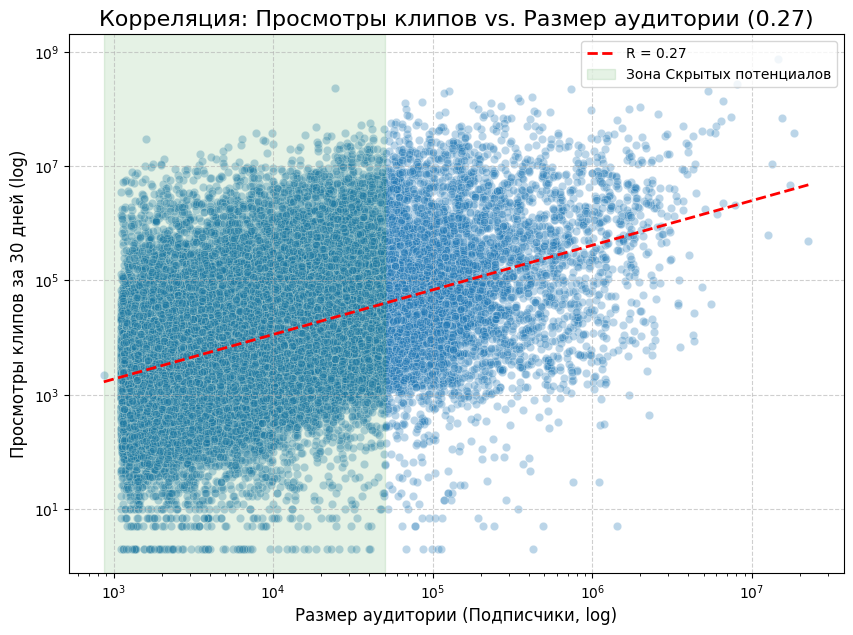

np.float64(0.268335685221853)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- ГРАФИК 1: Scatter Plot (Виральность vs. Размер аудитории) ---

plt.figure(figsize=(10, 7))
ax = plt.gca()

# Фильтрация и сэмплирование данных (для скорости и читаемости), убираем нули для логарифма
df_filtered = df[(df['Размер_аудитории'] > 0) & (df['Просмотры_клипов_30д'] > 0)].copy()
R_value = df_filtered['Размер_аудитории'].corr(df_filtered['Просмотры_клипов_30д'])
df_sample = df_filtered.sample(n=min(len(df_filtered), 50000), random_state=42)

sns.scatterplot(x='Размер_аудитории', y='Просмотры_клипов_30д', data=df_sample, alpha=0.3, color='#1f77b4', ax=ax)

# Расчет R-значения НАПРЯМУЮ ИЗ ДАННЫХ
R_value = df_filtered['Размер_аудитории'].corr(df_filtered['Просмотры_клипов_30д'])

# Установка логарифмических шкал
plt.xscale('log')
plt.yscale('log')

# Линия тренда (регрессия на логарифмах)
z = np.polyfit(np.log10(df_sample['Размер_аудитории']), np.log10(df_sample['Просмотры_клипов_30д']), 1)
p = np.poly1d(z)
x_trend = np.linspace(np.log10(df_sample['Размер_аудитории'].min()), np.log10(df_sample['Размер_аудитории'].max()), 100)
ax.plot(10**x_trend, 10**p(x_trend), "r--", label=f'R = {R_value:.2f}', linewidth=2)

# Визуализация зоны "Скрытых потенциалов" (для презентации)
# Находим пределы для заливки (логарифмические)
x_min_log = np.log10(df_sample['Размер_аудитории'].min())
x_max_potential = np.log10(50000) # log10(50000)
y_min_potential = 6 # log10(1000000)
y_max_log = np.log10(df_sample['Просмотры_клипов_30д'].max())

# Заливка области
ax.axvspan(10**x_min_log, 10**x_max_potential, ymin=(10**y_min_potential)/plt.ylim()[1], ymax=1,
          color='green', alpha=0.1, label='Зона Скрытых потенциалов')

plt.title(f'Корреляция: Просмотры клипов vs. Размер аудитории ({R_value:.2f})', fontsize=16)
plt.xlabel('Размер аудитории (Подписчики, log)', fontsize=12)
plt.ylabel('Просмотры клипов за 30 дней (log)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
R_value

/tmp/ipython-input-1570293728.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Метрика', y='Значение', data=df_compare, palette=['#a0a0a0', '#FF7F0E'])


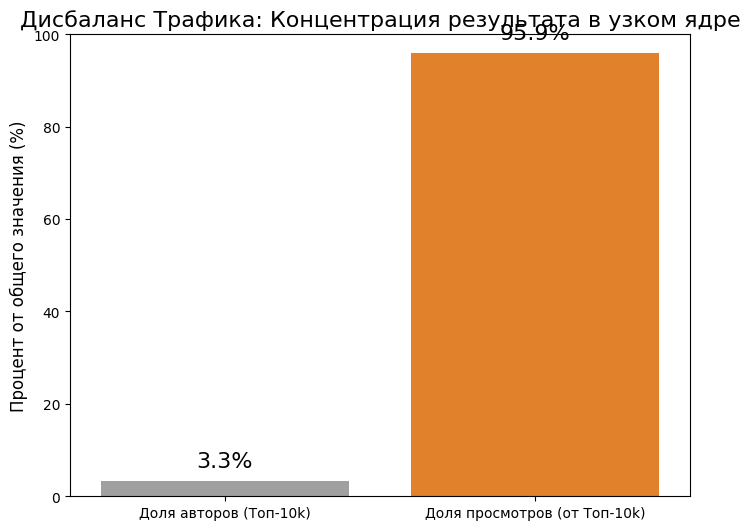

In [ ]:
# 1. Расчет необходимых значений НАПРЯМУЮ ИЗ ДАННЫХ
total_clips_views_all = df['Просмотры_клипов_30д'].sum()
total_authors = len(df) # Общее количество авторов

# 1.1. Доля авторов, которые входят в Топ-10k
top_10k_author_share = (10000 / total_authors) * 100

# 1.2. Доля просмотров от Топ-10k авторов
top_10k_views = df.sort_values(by='Просмотры_клипов_30д', ascending=False).head(10000)['Просмотры_клипов_30д'].sum()
top_10k_views_share = (top_10k_views / total_clips_views_all) * 100

# 2. Построение графика
data = {
    'Метрика': ['Доля авторов (Топ-10k)', 'Доля просмотров (от Топ-10k)'],
    'Значение': [top_10k_author_share, top_10k_views_share]
}
df_compare = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Метрика', y='Значение', data=df_compare, palette=['#a0a0a0', '#FF7F0E'])

plt.title('Дисбаланс Трафика: Концентрация результата в узком ядре', fontsize=16)
plt.ylim(0, 100)
plt.ylabel('Процент от общего значения (%)', fontsize=12)
plt.xlabel('')

# Добавление меток
plt.text(0, top_10k_author_share + 3, f'{top_10k_author_share:.1f}%', ha='center', fontsize=16, color='black')
plt.text(1, top_10k_views_share + 3, f'{top_10k_views_share:.1f}%', ha='center', fontsize=16, color='black')

plt.show()

In [ ]:
total_authors

305341

/tmp/ipython-input-3619650860.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Продуктивность', y='Доля авторов (%)', data=df_bar, palette=['#2ca02c', '#a0a0a0'])


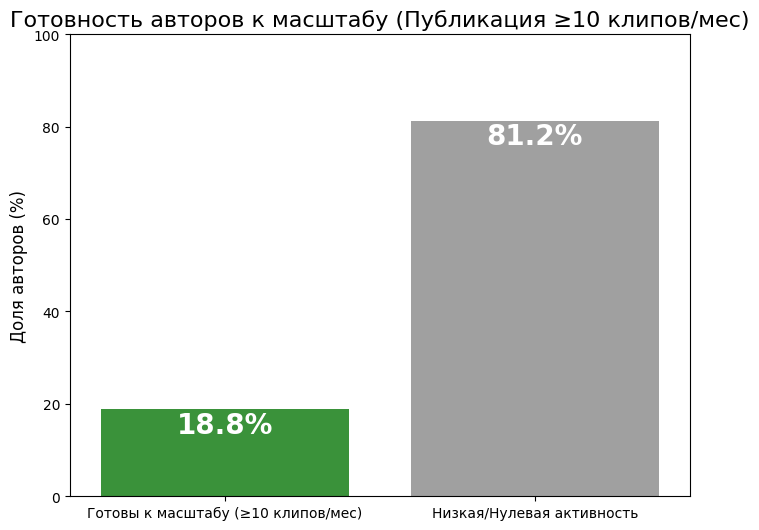

In [ ]:
# --- ГРАФИК 3: Bar Chart (Готовность к масштабу) ---

# 1. Расчет готовности к масштабу НАПРЯМУЮ ИЗ ДАННЫХ
# Используем метрику 'клипов_30д' (Клипы за 30 дней)
CLIPS_THRESHOLD = 10

total_authors = len(df)
# Авторы, готовые к масштабу (публикуют >= 10 клипов/мес)
high_clips_count = len(df[df['Клипов_30д'] >= CLIPS_THRESHOLD])

high_clips_percent = (high_clips_count / total_authors) * 100
low_clips_percent = 100 - high_clips_percent

# 2. Построение графика
data = {
    'Продуктивность': [f'Готовы к масштабу (≥{CLIPS_THRESHOLD} клипов/мес)', 'Низкая/Нулевая активность'],
    'Доля авторов (%)': [high_clips_percent, low_clips_percent]
}
df_bar = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
# Палитра: Зеленый (Потенциал) и Серый (Остальное)
sns.barplot(x='Продуктивность', y='Доля авторов (%)', data=df_bar, palette=['#2ca02c', '#a0a0a0'])

plt.title(f'Готовность авторов к масштабу (Публикация ≥{CLIPS_THRESHOLD} клипов/мес)', fontsize=16)
plt.ylabel('Доля авторов (%)', fontsize=12)
plt.xlabel('')

# Добавление процентных меток
plt.text(0, high_clips_percent - 5, f'{high_clips_percent:.1f}%', ha='center', fontsize=20, color='white', fontweight='bold')
plt.text(1, low_clips_percent - 5, f'{low_clips_percent:.1f}%', ha='center', fontsize=20, color='white', fontweight='bold')

plt.ylim(0, 100)
plt.show()

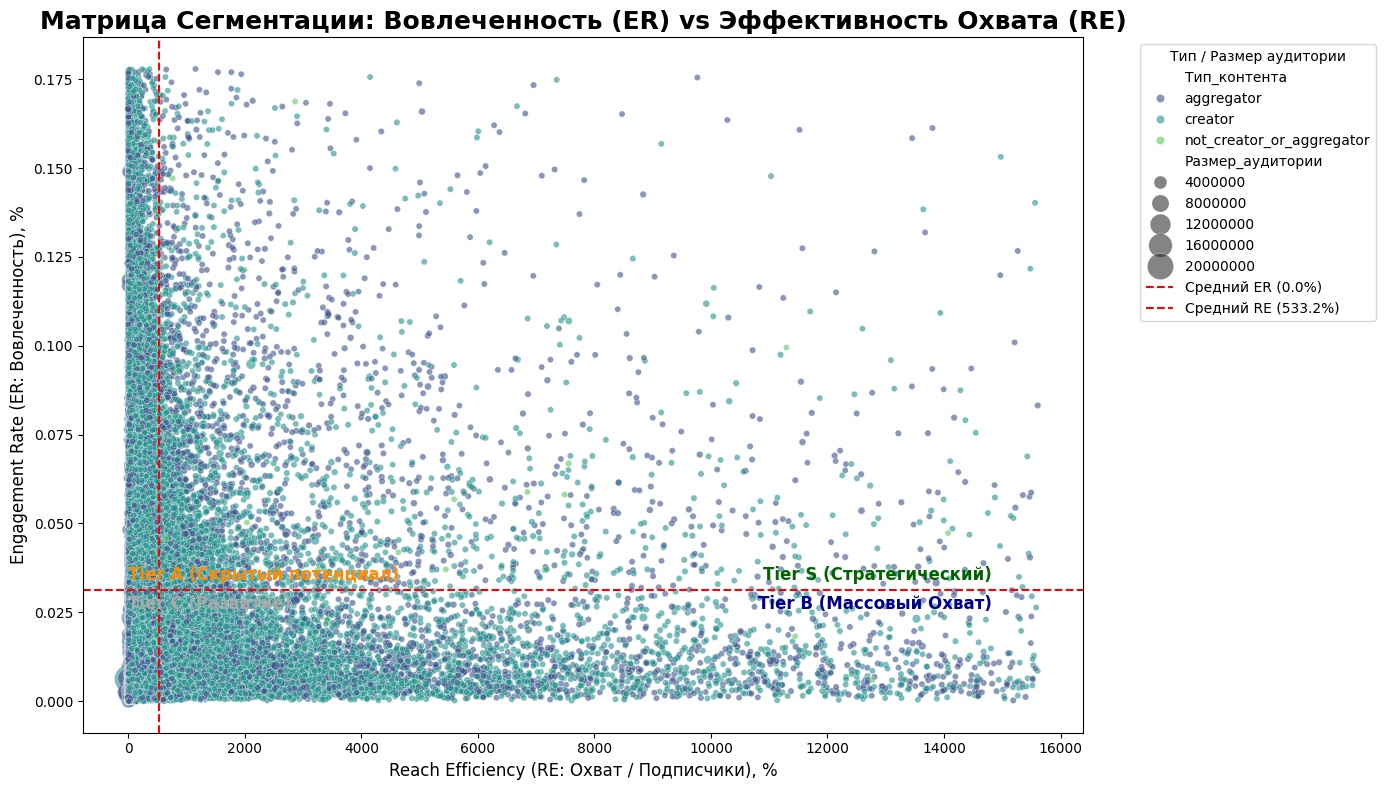

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- ГРАФИК 1: Матрица Сегментации (Вовлеченность vs. Эффективность Охвата) ---

# 1. Расчет ER (Engagement Rate) и RE (Reach Efficiency) для df_clips
# ER уже рассчитан как 'Коэффициент_вовлеченности' в df_clips
# RE = (Охват_клипов_30д / Размер_аудитории) * 100

df_clips['Reach_Efficiency'] = (df_clips['Охват_клипов_30д'] / df_clips['Размер_аудитории']) * 100

# 2. Фильтрация выбросов
# Используем уже созданные русские названия столбцов
q_er = df_clips['Коэффициент_вовлеченности'].quantile(0.98)
q_re = df_clips['Reach_Efficiency'].quantile(0.98)
plot_data = df_clips[(df_clips['Коэффициент_вовлеченности'] < q_er) & (df_clips['Reach_Efficiency'] < q_re)]

# 3. Расчет средних значений для разделения квадрантов
avg_er = plot_data['Коэффициент_вовлеченности'].mean()
avg_re = plot_data['Reach_Efficiency'].mean()

plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(
    data=plot_data,
    x='Reach_Efficiency',
    y='Коэффициент_вовлеченности',
    hue='Тип_контента', # Используем для цвета
    size='Размер_аудитории',    # Используем размер точки для отражения аудитории
    sizes=(20, 400),
    alpha=0.6,
    palette='viridis'
)

# 4. Разделение квадрантов (Средние линии)
plt.axhline(y=avg_er, color='r', linestyle='--', label=f'Средний ER ({avg_er:.1f}%)')
plt.axvline(x=avg_re, color='r', linestyle='--', label=f'Средний RE ({avg_re:.1f}%)')

# 5. Подписи квадрантов (Тиры)
plt.text(plot_data['Reach_Efficiency'].max() * 0.95, avg_er * 1.05, 'Tier S (Стратегический)',
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='darkgreen')
plt.text(plot_data['Reach_Efficiency'].min() * 1.05, avg_er * 1.05, 'Tier A (Скрытый потенциал)',
         ha='left', va='bottom', fontsize=12, fontweight='bold', color='darkorange')
plt.text(plot_data['Reach_Efficiency'].max() * 0.95, avg_er * 0.95, 'Tier B (Массовый Охват)',
         ha='right', va='top', fontsize=12, fontweight='bold', color='darkblue')
plt.text(plot_data['Reach_Efficiency'].min() * 1.05, avg_er * 0.95, 'Tier C (Развитие)',
         ha='left', va='top', fontsize=12, fontweight='bold', color='darkgrey')


plt.title('Матрица Сегментации: Вовлеченность (ER) vs Эффективность Охвата (RE)', fontsize=18, fontweight='bold')
plt.xlabel('Reach Efficiency (RE: Охват / Подписчики), %', fontsize=12)
plt.ylabel('Engagement Rate (ER: Вовлеченность), %', fontsize=12)

# Настройка легенды для размера и цвета
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, labels, title='Тип / Размер аудитории', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
conditions = [
    (df_clips['Коэффициент_вовлеченности'] > avg_er) & (df_clips['Reach_Efficiency'] > avg_re),
    (df_clips['Коэффициент_вовлеченности'] > avg_er) & (df_clips['Reach_Efficiency'] <= avg_re),
    (df_clips['Коэффициент_вовлеченности'] <= avg_er) & (df_clips['Reach_Efficiency'] > avg_re),
    (df_clips['Коэффициент_вовлеченности'] <= avg_er) & (df_clips['Reach_Efficiency'] <= avg_re)
]

choices = ['Tier S', 'Tier A', 'Tier B', 'Tier C']

df_clips['Сегмент'] = np.select(conditions, choices, default='Unknown')

print("Распределение авторов по сегментам:")
display(df_clips['Сегмент'].value_counts().to_frame())


Распределение авторов по сегментам:


,count
Сегмент,
Tier C,55012
Tier A,34899
Tier B,14461
Tier S,5606


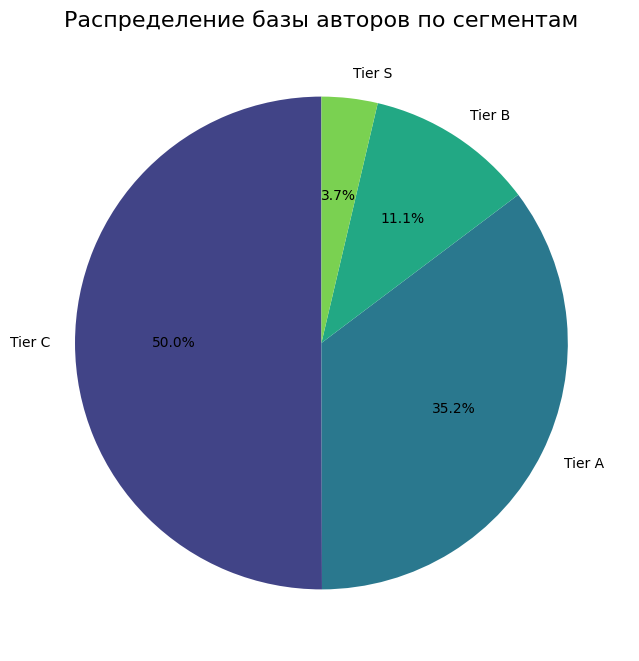

In [ ]:
# --- ГРАФИК 1: Распределение базы (Pie Chart) ---
data_count = {
    'Сегмент': ['Tier C', 'Tier A', 'Tier B', 'Tier S'],
    'count': [4155, 2926, 918, 305]
}
df_count = pd.DataFrame(data_count)

plt.figure(figsize=(8, 8))
plt.pie(df_count['count'],
        labels=df_count['Сегмент'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('viridis', len(df_count)))

plt.title('Распределение базы авторов по сегментам', fontsize=16)
plt.show()

In [ ]:
grouped_content_type = df_clips.groupby(['Сегмент', 'Тип_контента'])['Коэффициент_вовлеченности'].mean().reset_index()
grouped_content_type.rename(columns={'Коэффициент_вовлеченности': 'Средний_коэффициент_вовлеченности'}, inplace=True)

grouped_content_type.sort_values(by='Средний_коэффициент_вовлеченности', ascending=False, inplace=True)

print("Анализ среднего коэффициента вовлеченности по сегментам и типу контента:")
display(grouped_content_type.head(20))

Анализ среднего коэффициента вовлеченности по сегментам и типу контента:


,Сегмент,Тип_контента,Средний_коэффициент_вовлеченности
2,Tier A,not_creator_or_aggregator,0.105859
0,Tier A,aggregator,0.090681
9,Tier S,aggregator,0.081832
1,Tier A,creator,0.078212
11,Tier S,not_creator_or_aggregator,0.078097
10,Tier S,creator,0.064239
8,Tier C,not_creator_or_aggregator,0.014723
7,Tier C,creator,0.014125
5,Tier B,not_creator_or_aggregator,0.014058
4,Tier B,creator,0.011792


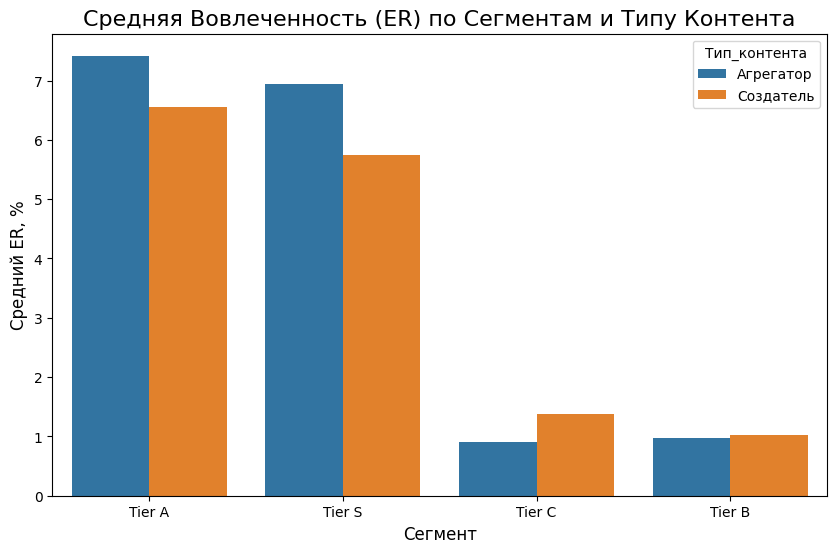

In [ ]:
# --- ГРАФИК 2: ER по типу контента ---
data_content = {
    'Сегмент': ['Tier A', 'Tier S', 'Tier A', 'Tier S', 'Tier C', 'Tier B', 'Tier B', 'Tier C'],
    'Тип_контента': ['Агрегатор', 'Агрегатор', 'Создатель', 'Создатель', 'Создатель', 'Создатель', 'Агрегатор', 'Агрегатор'],
    'ER': [0.07418, 0.06933, 0.06557, 0.05738, 0.01372, 0.01032, 0.00980, 0.00914]
}
df_content = pd.DataFrame(data_content)
df_content['ER_Percent'] = df_content['ER'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Сегмент', y='ER_Percent', hue='Тип_контента', data=df_content.sort_values(by='ER_Percent', ascending=False))

plt.title('Средняя Вовлеченность (ER) по Сегментам и Типу Контента', fontsize=16)
plt.ylabel('Средний ER, %', fontsize=12)
plt.xlabel('Сегмент', fontsize=12)
plt.show()

In [ ]:
grouped_category_type = df_clips.groupby(['Сегмент', 'Категория'])['Коэффициент_вовлеченности'].mean().reset_index()
grouped_category_type.rename(columns={'Коэффициент_вовлеченности': 'Средний_коэффициент_вовлеченности'}, inplace=True)

grouped_category_type.sort_values(by=['Сегмент', 'Средний_коэффициент_вовлеченности'], ascending=[True, False], inplace=True)

print("Анализ среднего коэффициента вовлеченности по сегментам и категориям:")

top_categories_per_segment = []
for segment in grouped_category_type['Сегмент'].unique():
    top_categories_per_segment.append(grouped_category_type[grouped_category_type['Сегмент'] == segment].head(3))

final_display_df = pd.concat(top_categories_per_segment)
final_display_df.sort_values(by='Средний_коэффициент_вовлеченности', ascending=False, inplace=True)
display(final_display_df)

Анализ среднего коэффициента вовлеченности по сегментам и категориям:


,Сегмент,Категория,Средний_коэффициент_вовлеченности
31,Tier A,FINANCE,0.772293
36,Tier A,JOB,0.205831
16,Tier A,COMPANY_INTERNET,0.188932
155,Tier S,FINANCE,0.178719
129,Tier S,CLASSIFIED,0.138422
145,Tier S,COMPANY_SERVICE,0.108929
89,Tier C,COMPANY_ANIMALS,0.018567
83,Tier C,ANIMALS,0.018158
93,Tier C,COMPANY_CULTURE,0.017531
41,Tier B,ANIMALS,0.016453
